In [1]:
!pip install -q transformers datasets trl peft bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 10.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.0 MB/s eta 0:00:00:00:0100:01


 PHASE 1: DATA PREPROCESSING & EDA

1/3 DOWNLOADING & LOADING DATASETS


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-b42a775f407cee(…):   0%|          | 0.00/39.5M [00:00<?, ?B/s]

data/validation-00000-of-00001-134b8fd0c(…):   0%|          | 0.00/2.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/84437 [00:00<?, ? examples/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1062 > 1024). Running this sequence through the model will result in indexing errors


   Tokenizer Model      : gpt2
   Vocabulary Size      : 50,257 tokens
   Max Context Length   : 1024 tokens
   Sample 0 Token Count : 18 tokens

DATA INSPECTION (Sample 0 from oasst1):
--------------------------------------------------
Human: What city was she born in?

Assistant: She was born in Paris[TRUNCATED FOR DISPLAY]
--------------------------------------------------

GENERATING TOKEN LENGTH VISUALIZATION


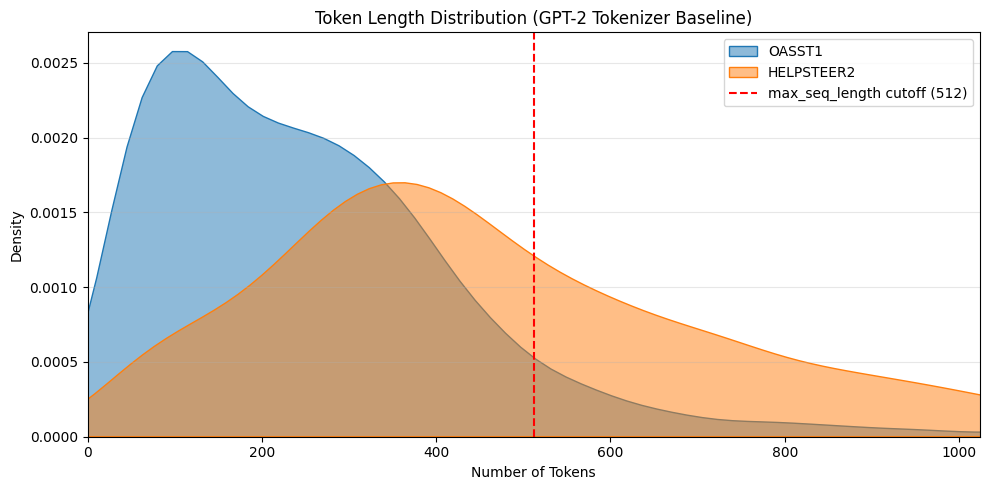

Phase 1 Complete. Data is verified and ready for SFT.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from collections import defaultdict

print("="*60)
print(" PHASE 1: DATA PREPROCESSING & EDA")
print("="*60)

SAMPLES = 5000

print("\n1/3 DOWNLOADING & LOADING DATASETS")

raw_oasst     = load_dataset("OpenAssistant/oasst1", split="train")
raw_helpsteer = load_dataset("nvidia/HelpSteer2", split="train")

print(f"   oasst1 raw messages   : {len(raw_oasst):,}")
print(f"   oasst1 columns        : {raw_oasst.column_names}")
print(f"   HelpSteer2 raw rows   : {len(raw_helpsteer):,}")
print(f"   HelpSteer2 columns    : {raw_helpsteer.column_names}")

print("\n2/3 PREPROCESSING & FORMATTING")

msg_lookup = {row["message_id"]: row for row in raw_oasst}

oasst_pairs = []
for row in raw_oasst:
    if (row["role"] == "assistant"
            and row["lang"] == "en"
            and not row["deleted"]
            and row["rank"] == 0
            and row["parent_id"] in msg_lookup):
        parent = msg_lookup[row["parent_id"]]
        if parent["role"] == "prompter" and not parent["deleted"]:
            oasst_pairs.append({
                "prompt":   parent["text"].strip(),
                "response": row["text"].strip(),
            })

oasst_pairs = oasst_pairs[:SAMPLES]
print(f"   oasst1 valid pairs    : {len(oasst_pairs):,}")

helpsteer_samples = []
rows = list(raw_helpsteer)
i = 0
while i < len(rows) - 1:
    a, b = rows[i], rows[i+1]
    if a["prompt"] == b["prompt"]:
        best = a if a["helpfulness"] >= b["helpfulness"] else b
        helpsteer_samples.append({
            "prompt":   best["prompt"].strip(),
            "response": best["response"].strip(),
        })
        i += 2
    else:
        i += 1

helpsteer_samples = helpsteer_samples[:SAMPLES]
print(f"   HelpSteer2 valid pairs: {len(helpsteer_samples):,}")

def make_sft_dataset(pairs):
    texts = [f"Human: {p['prompt']}\n\nAssistant: {p['response']}" for p in pairs]
    return Dataset.from_dict({"text": texts})

oasst_sft     = make_sft_dataset(oasst_pairs)
helpsteer_sft = make_sft_dataset(helpsteer_samples)

oasst_splits     = oasst_sft.train_test_split(test_size=0.1, seed=42)
helpsteer_splits = helpsteer_sft.train_test_split(test_size=0.1, seed=42)

datasets_dict = {
    "oasst1":     oasst_splits,
    "helpsteer2": helpsteer_splits,
}

print(f"\n   Train/Val Splits created (90/10).")
print(f"   oasst1     | Train: {len(oasst_splits['train']):,} | Val: {len(oasst_splits['test']):,}")
print(f"   helpsteer2 | Train: {len(helpsteer_splits['train']):,} | Val: {len(helpsteer_splits['test']):,}")

print("\n3/3 LOADING TOKENIZER FOR EDA")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
print(f"   Tokenizer Model      : gpt2")
print(f"   Vocabulary Size      : {tokenizer.vocab_size:,} tokens")
print(f"   Max Context Length   : {tokenizer.model_max_length} tokens")

sample_text   = oasst_splits["train"][0]["text"]
sample_tokens = tokenizer(sample_text)
print(f"   Sample 0 Token Count : {len(sample_tokens['input_ids'])} tokens")

print("\nDATA INSPECTION (Sample 0 from oasst1):")
print("-" * 50)
print(oasst_splits["train"][0]["text"][:350] + "[TRUNCATED FOR DISPLAY]")
print("-" * 50)

print("\nGENERATING TOKEN LENGTH VISUALIZATION")

def plot_token_lengths(datasets_dict, tokenizer):
    plt.figure(figsize=(10, 5))
    for ds_name, splits in datasets_dict.items():
        lengths = [len(tokenizer(text)["input_ids"]) for text in splits["train"]["text"]]
        sns.kdeplot(lengths, fill=True, label=ds_name.upper(), alpha=0.5)
    plt.title("Token Length Distribution (GPT-2 Tokenizer Baseline)")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Density")
    plt.xlim(0, 1024)
    plt.axvline(x=512, color="red", linestyle="--", label="max_seq_length cutoff (512)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("./phase1_token_dist.png", dpi=150)
    plt.show()

plot_token_lengths(datasets_dict, tokenizer)
print("Phase 1 Complete. Data is verified and ready for SFT.")

In [3]:
import torch
import gc
from datasets import load_dataset, Dataset
from collections import defaultdict
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

SAMPLES = 5000

print("\n1/4 LOADING DATASETS")

raw_oasst     = load_dataset("OpenAssistant/oasst1", split="train")
raw_helpsteer = load_dataset("nvidia/HelpSteer2", split="train")

msg_lookup = {row["message_id"]: row for row in raw_oasst}

oasst_pairs = []
for row in raw_oasst:
    if (row["role"] == "assistant" and row["lang"] == "en"
            and not row["deleted"] and row["rank"] == 0
            and row["parent_id"] in msg_lookup):
        parent = msg_lookup[row["parent_id"]]
        if parent["role"] == "prompter" and not parent["deleted"]:
            oasst_pairs.append({
                "prompt":   parent["text"].strip(),
                "response": row["text"].strip(),
            })

helpsteer_samples = []
rows = list(raw_helpsteer)
i = 0
while i < len(rows) - 1:
    a, b = rows[i], rows[i+1]
    if a["prompt"] == b["prompt"]:
        best = a if a["helpfulness"] >= b["helpfulness"] else b
        helpsteer_samples.append({
            "prompt":   best["prompt"].strip(),
            "response": best["response"].strip(),
        })
        i += 2
    else:
        i += 1

def make_sft_dataset(pairs, n=SAMPLES):
    texts = [f"Human: {p['prompt']}\n\nAssistant: {p['response']}" for p in pairs[:n]]
    return Dataset.from_dict({"text": texts})

oasst_sft     = make_sft_dataset(oasst_pairs)
helpsteer_sft = make_sft_dataset(helpsteer_samples)

datasets_dict = {
    "oasst1":     oasst_sft.train_test_split(test_size=0.1, seed=42),
    "helpsteer2": helpsteer_sft.train_test_split(test_size=0.1, seed=42),
}

print(f"   oasst1     | Train: {len(datasets_dict['oasst1']['train']):,} | Val: {len(datasets_dict['oasst1']['test']):,}")
print(f"   helpsteer2 | Train: {len(datasets_dict['helpsteer2']['train']):,} | Val: {len(datasets_dict['helpsteer2']['test']):,}")

print("\n2/4 BUILDING TRAINING CONFIG")

def make_sft_args(alias, ds_name):
    use_paged = "pythia" in alias
    return SFTConfig(
        output_dir=f"./models/sft/{alias}_{ds_name}",
        dataset_text_field="text",
        max_length=512,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        save_strategy="epoch",
        eval_strategy="epoch",
        logging_steps=20,
        num_train_epochs=1,
        optim="paged_adamw_32bit" if use_paged else "adamw_torch",
        fp16=False,
        bf16=False,
        report_to="none",
    )

def run_sft(model, tok, ds_name, splits, alias):
    print(f"\n{'-'*50}")
    print(f"STARTING SFT: {alias.upper()} on {ds_name.upper()}")
    print(f"{'-'*50}")
    out = f"./models/sft/{alias}_{ds_name}"
    args = make_sft_args(alias, ds_name)
    trainer = SFTTrainer(
        model=model,
        train_dataset=splits["train"],
        eval_dataset=splits["test"],
        processing_class=tok,
        args=args,
    )
    trainer.train()
    trainer.model.save_pretrained(out)
    tok.save_pretrained(out)
    print(f"Saved to {out}")

print("\n3/4 TRAINING GPT-2")

lora_gpt2 = LoraConfig(r=16, lora_alpha=32, task_type="CAUSAL_LM", fan_in_fan_out=True)
tok_gpt2  = AutoTokenizer.from_pretrained("gpt2")
tok_gpt2.pad_token = tok_gpt2.eos_token
mdl_gpt2  = AutoModelForCausalLM.from_pretrained("gpt2")
mdl_gpt2  = get_peft_model(mdl_gpt2, lora_gpt2)
print(f"   GPT-2 trainable params: ", end="")
mdl_gpt2.print_trainable_parameters()

for ds_name, splits in datasets_dict.items():
    run_sft(mdl_gpt2, tok_gpt2, ds_name, splits, "gpt2")

del mdl_gpt2, tok_gpt2
gc.collect()
if device == "cuda": torch.cuda.empty_cache()
print("GPT-2 released from memory.")

print("\n4/4 TRAINING PYTHIA-1B")

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

lora_pythia = LoraConfig(r=16, lora_alpha=32, task_type="CAUSAL_LM")
tok_pythia  = AutoTokenizer.from_pretrained("EleutherAI/pythia-1b")
tok_pythia.pad_token = tok_pythia.eos_token

mdl_pythia = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-1b",
    quantization_config=bnb,
    device_map="auto",
    torch_dtype=torch.float16,
)
mdl_pythia = get_peft_model(mdl_pythia, lora_pythia)

for name, param in mdl_pythia.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float16)

print(f"   Pythia-1B trainable params: ", end="")
mdl_pythia.print_trainable_parameters()

for ds_name, splits in datasets_dict.items():
    run_sft(mdl_pythia, tok_pythia, ds_name, splits, "pythia1b")

del mdl_pythia, tok_pythia
gc.collect()
if device == "cuda": torch.cuda.empty_cache()
print("Pythia-1B released from memory.")

print("\nPhase 2 complete — all 4 models trained and saved.")
print("Saved under: ./models/sft/")
print("├── gpt2_oasst1/")
print("├── gpt2_helpsteer2/")
print("├── pythia1b_oasst1/")
print("└── pythia1b_helpsteer2/")

Using device: cuda

1/4 LOADING DATASETS
   oasst1     | Train: 4,500 | Val: 500
   helpsteer2 | Train: 4,500 | Val: 500

2/4 BUILDING TRAINING CONFIG

3/4 TRAINING GPT-2


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

   GPT-2 trainable params: trainable params: 589,824 || all params: 125,029,632 || trainable%: 0.4717

--------------------------------------------------
STARTING SFT: GPT2 on OASST1
--------------------------------------------------


...

Adding EOS to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,1.826551,1.769488


Saved to ./models/sft/pythia1b_helpsteer2
Pythia-1B released from memory.

Phase 2 complete — all 4 models trained and saved.
Saved under: ./models/sft/
├── gpt2_oasst1/
├── gpt2_helpsteer2/
├── pythia1b_oasst1/
└── pythia1b_helpsteer2/


In [4]:
import torch
import torch.nn as nn
import gc
from datasets import load_dataset, Dataset
from collections import defaultdict
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import RewardTrainer, RewardConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

SAMPLES = 5000

class DtypeSafeScoreHead(nn.Module):
    def __init__(self, original_score):
        super().__init__()
        self.score = original_score
    def forward(self, x):
        return self.score(x.to(self.score.weight.dtype))

def wrap_score_head(model):
    sw     = model.base_model.model.score
    active = sw.active_adapters[0]
    sw.modules_to_save[active] = DtypeSafeScoreHead(sw.modules_to_save[active])
    print("   Score head wrapped with DtypeSafeScoreHead")
    return model

print("\n1/4 LOADING & FORMATTING PREFERENCE DATA")

raw_oasst  = load_dataset("OpenAssistant/oasst1", split="train")
raw_helpsteer = load_dataset("nvidia/HelpSteer2", split="train")

msg_lookup = {row["message_id"]: row for row in raw_oasst}

parent_replies = defaultdict(list)
for row in raw_oasst:
    if row["role"] == "assistant" and row["lang"] == "en" and not row["deleted"]:
        parent_replies[row["parent_id"]].append(row)

oasst_rm_pairs = []
for parent_id, replies in parent_replies.items():
    if parent_id not in msg_lookup:
        continue
    parent = msg_lookup[parent_id]
    if parent["role"] != "prompter" or parent["deleted"]:
        continue
    sorted_replies = sorted(replies, key=lambda r: r["rank"] if r["rank"] is not None else 999)
    if len(sorted_replies) >= 2:
        prompt   = f"Human: {parent['text'].strip()}\n\nAssistant:"
        chosen   = f"{prompt} {sorted_replies[0]['text'].strip()}"
        rejected = f"{prompt} {sorted_replies[1]['text'].strip()}"
        oasst_rm_pairs.append({"chosen": chosen, "rejected": rejected})

oasst_rm_pairs = oasst_rm_pairs[:SAMPLES]
print(f"   oasst1 preference pairs     : {len(oasst_rm_pairs):,}")

rows = list(raw_helpsteer)
helpsteer_rm_pairs = []
i = 0
while i < len(rows) - 1:
    a, b = rows[i], rows[i+1]
    if a["prompt"] == b["prompt"]:
        if a["helpfulness"] != b["helpfulness"]:
            hi = a if a["helpfulness"] > b["helpfulness"] else b
            lo = b if hi is a else a
            prompt   = f"Human: {hi['prompt'].strip()}\n\nAssistant:"
            chosen   = f"{prompt} {hi['response'].strip()}"
            rejected = f"{prompt} {lo['response'].strip()}"
            helpsteer_rm_pairs.append({"chosen": chosen, "rejected": rejected})
        i += 2
    else:
        i += 1

helpsteer_rm_pairs = helpsteer_rm_pairs[:SAMPLES]
print(f"   helpsteer2 preference pairs : {len(helpsteer_rm_pairs):,}")

def make_rm_dataset(pairs):
    return Dataset.from_dict({
        "chosen":   [p["chosen"]   for p in pairs],
        "rejected": [p["rejected"] for p in pairs],
    })

datasets_dict = {
    "oasst1":     make_rm_dataset(oasst_rm_pairs).train_test_split(test_size=0.1, seed=42),
    "helpsteer2": make_rm_dataset(helpsteer_rm_pairs).train_test_split(test_size=0.1, seed=42),
}

print(f"   oasst1     | Train: {len(datasets_dict['oasst1']['train']):,} | Val: {len(datasets_dict['oasst1']['test']):,}")
print(f"   helpsteer2 | Train: {len(datasets_dict['helpsteer2']['train']):,} | Val: {len(datasets_dict['helpsteer2']['test']):,}")

print("\n2/4 BUILDING REWARD CONFIG")

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

base_rm_args = RewardConfig(
    output_dir="./models/reward_models",
    max_length=512,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=20,
    num_train_epochs=1,
    optim="paged_adamw_32bit",
    fp16=False,
    bf16=False,
    report_to="none",
)

def run_rm(model, tok, ds_name, splits, alias):
    print(f"\n{'-'*50}")
    print(f"STARTING RM: {alias.upper()} on {ds_name.upper()}")
    print(f"{'-'*50}")
    out = f"./models/reward_models/{alias}_{ds_name}"
    base_rm_args.output_dir = out
    trainer = RewardTrainer(
        model=model,
        processing_class=tok,
        args=base_rm_args,
        train_dataset=splits["train"],
        eval_dataset=splits["test"],
    )
    trainer.train()
    trainer.model.save_pretrained(out)
    tok.save_pretrained(out)
    print(f"Saved to {out}")

print("\n3/4 TRAINING GPT-2 REWARD MODEL")

lora_gpt2 = LoraConfig(r=16, lora_alpha=32, task_type=TaskType.SEQ_CLS, fan_in_fan_out=True)
tok_gpt2  = AutoTokenizer.from_pretrained("gpt2")
tok_gpt2.pad_token = tok_gpt2.eos_token
mdl_gpt2  = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=1)
mdl_gpt2.config.pad_token_id = tok_gpt2.pad_token_id
mdl_gpt2  = get_peft_model(mdl_gpt2, lora_gpt2)
print(f"   GPT-2 trainable params: ", end="")
mdl_gpt2.print_trainable_parameters()

for ds_name, splits in datasets_dict.items():
    run_rm(mdl_gpt2, tok_gpt2, ds_name, splits, "gpt2")

del mdl_gpt2, tok_gpt2
gc.collect()
if device == "cuda": torch.cuda.empty_cache()
print("GPT-2 released from memory.")

print("\n4/4 TRAINING PYTHIA-1B REWARD MODEL")

lora_pythia = LoraConfig(r=16, lora_alpha=32, task_type=TaskType.SEQ_CLS)
tok_pythia  = AutoTokenizer.from_pretrained("EleutherAI/pythia-1b")
tok_pythia.pad_token = tok_pythia.eos_token

mdl_pythia = AutoModelForSequenceClassification.from_pretrained(
    "EleutherAI/pythia-1b",
    num_labels=1,
    quantization_config=bnb,
    device_map="auto",
    torch_dtype=torch.float16,
)
mdl_pythia.config.pad_token_id = tok_pythia.pad_token_id
mdl_pythia = get_peft_model(mdl_pythia, lora_pythia)

for name, param in mdl_pythia.named_parameters():
    if param.requires_grad and "score" not in name:
        param.data = param.data.to(torch.float16)

mdl_pythia = wrap_score_head(mdl_pythia)
print(f"   Pythia-1B trainable params: ", end="")
mdl_pythia.print_trainable_parameters()

for ds_name, splits in datasets_dict.items():
    run_rm(mdl_pythia, tok_pythia, ds_name, splits, "pythia1b")

del mdl_pythia, tok_pythia
gc.collect()
if device == "cuda": torch.cuda.empty_cache()
print("Pythia-1B released from memory.")

print("\nPhase 3 complete — all reward models trained and saved.")
print("Saved under: ./models/reward_models/")
print("├── gpt2_oasst1/")
print("├── gpt2_helpsteer2/")
print("├── pythia1b_oasst1/")
print("└── pythia1b_helpsteer2/")

Using device: cuda

1/4 LOADING & FORMATTING PREFERENCE DATA
   oasst1 preference pairs     : 5,000
   helpsteer2 preference pairs : 5,000
   oasst1     | Train: 4,500 | Val: 500
   helpsteer2 | Train: 4,500 | Val: 500

2/4 BUILDING REWARD CONFIG

3/4 TRAINING GPT-2 REWARD MODEL


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   GPT-2 trainable params: trainable params: 590,592 || all params: 125,031,168 || trainable%: 0.4724

--------------------------------------------------
STARTING RM: GPT2 on OASST1
--------------------------------------------------


Adding EOS to train dataset:   0%|          | 0/4500 [00:00<?, ? examples/s]

...

Adding EOS to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Filtering eval >512 tokens:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.794629,0.729428


Saved to ./models/reward_models/pythia1b_helpsteer2
Pythia-1B released from memory.

Phase 3 complete — all reward models trained and saved.
Saved under: ./models/reward_models/
├── gpt2_oasst1/
├── gpt2_helpsteer2/
├── pythia1b_oasst1/
└── pythia1b_helpsteer2/
